# Preamble

In [1]:
import numpy as np
import scipy.integrate as itg
import scipy.linalg as spla
import matplotlib as mpl
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d as mplot3d
from cycler import cycler

plt.style.use('dark_background')
mpl.rcParams['axes.prop_cycle'] = cycler(color=mpl.color_sequences['Pastel1'])
mpl.rcParams['figure.facecolor'] = 'xkcd:dark'
mpl.rcParams['axes.facecolor'] = 'none'
mpl.rcParams['axes3d.xaxis.panecolor'] = (1.0, 0.5, 0.5, 0.0625)
mpl.rcParams['axes3d.yaxis.panecolor'] = (1.0, 0.5, 1.0, 0.0625)
mpl.rcParams['axes3d.zaxis.panecolor'] = (0.0, 0.5, 1.0, 0.0625)

mpl.rcParams['grid.color'] = (1.0, 1.0, 1.0, 0.125)

log_scale_kwargs = dict(base=16, subs=np.arange(2, 5))

# Scalar ODE for eigenvalues

Bernoulli differential equation: $y' = y - y^3.$ If $y_0 \in {0, \pm 1}$ then $y = y_0.$ Otherwise substitute $v := y^{-2},$ get
$$v' = -2y^{-3} y' = -2 y^{-3} (y - y^3) = 2(1-v).$$
Then
$$1-v = 1-y^{-2} = C\exp(-2t)$$
so
$$y = \pm(1-C\exp(-2t))^{-1/2}.$$
In terms of initial conditions
$$C = 1-y_0^{-2}.$$
Finally
$$y = \frac{\operatorname{sgn} y_0}{\sqrt{1-(1-y_0^{-2})\exp(-2t)}} = \frac{y_0}{\sqrt{1 + (1-y_0^2)(\exp(-2t)-1)}} := \frac{y_0}{\sqrt{\Delta(t, y_0)}}.$$
This expression is valid for $t > t_* = \frac{1}{2} \log \left( 1 - y_0^{-2} \right)$ when $|y_0| > 1.$ If $|y_0| < 1,$ it is valid for all $t.$ This is equivalent to checking if the determinant $\Delta(t, y_0) > 0.$ Since ODE is autonomous, all solutions for various $t_0$ can be gotten by simple shifts.

In [2]:
def fun(t, y):
    return y * (1.0 - y * y)


def y_exact(t, y0):
    if y0 in (0.0, 1.0, -1.0): return np.full_like(t, y0)
    determinant = 1.0 + (1.0 - y0*y0) * np.expm1(-2.0*t)
    return y0 * np.where(
        determinant > 0.0,
        np.reciprocal(np.sqrt(determinant)),
        np.full_like(t, np.inf),
    )

# Naive RK and Euler

The first method is explicit Euler, and we will take advantage of `scipy`'s existing infrastructure for solving IVPs. Butcher tableau notation from the Hairer, Nørsett, Wanner book:
$$
\def\arraystretch{1.5}\begin{array}{c|c}
   C & A \\ \hline
     & B^T \\
\end{array} =
\def\arraystretch{1.0}\begin{array}{c|c}
   0      &  \\
   c_2    & a_{21} \\
   \vdots & \vdots & \ddots \\
   c_S    & a_{S1}   & \cdots & a_{S,S-1} \\
   \hline
          & b_1 & \cdots & b_{S-1} & b_S \\
\end{array}
$$
where for each stage $s = 1, \ldots, S,$ we find entry of $K = (k_1 \quad \cdots \quad k_S \quad k_{S+1})^T,$
$$
k_s = f\left(t_0 + c_s h\ ,\ y_0 + h \sum_{i=1}^{s-1} a_{si} k_i \right),
$$
and the result of the step is $y_1 = y_0 + h B^T K.$ The next slope $k_{S+1} = f(t_0 + h, y_1)$ is also computed.

In [3]:
from scipy.integrate._ivp.rk import RungeKutta, rk_step

class RK11(RungeKutta):
    order = 1
    error_estimator_order = 1
    n_stages = 1
    C = np.array([0.0])
    A = np.array([[0.0]])
    B = np.array([1.0])
    E = np.array([-0.5, 0.5])
    P = np.array([[1.0,  1, -1],
                  [  0, -1,  1]])


In [4]:
class NaiveRungeKutta(RungeKutta):
    def __init__(self, fun, t0, y0, t_bound, num_steps=50,
                 rtol=1e-3, atol=1e-6, vectorized=False, **extraneous):
        itg._ivp.common.warn_extraneous(extraneous)

        self.num_steps = num_steps
        self.steps_taken = 0
        self.step_ts = np.linspace(t0, t_bound, num_steps + 1)
        max_step = np.max(np.abs(self.step_ts[1:] - self.step_ts[:-1]))
        first_step = np.abs(self.step_ts[1] - self.step_ts[0])

        super().__init__(fun, t0, y0, t_bound, max_step=max_step,
                 rtol=rtol, atol=atol, vectorized=vectorized,
                 first_step=first_step)

    def _step_impl(self):
        t = self.t
        y = self.y

        rtol = self.rtol
        atol = self.atol

        min_step = 10 * np.abs(np.nextafter(t, self.direction * np.inf) - t)

        t_new = self.step_ts[self.steps_taken + 1]
        h = t_new - t
        h_abs = np.abs(h)

        if h_abs < min_step:
            return False, self.TOO_SMALL_STEP

        y_new, f_new = rk_step(self.fun, t, y, self.f, h, self.A,
                                self.B, self.C, self.K)
        scale = atol + np.maximum(np.abs(y), np.abs(y_new)) * rtol
        error_norm = self._estimate_error_norm(self.K, h, scale)

        self.h_previous = h
        self.y_old = y

        self.t = t_new
        self.y = y_new

        self.h_abs = h_abs
        self.f = f_new
        self.steps_taken += 1

        return True, None


class NaiveRK11(NaiveRungeKutta, RK11):
    pass
class NaiveRK23(NaiveRungeKutta, itg.RK23):
    pass

# Matrix differential equations

In [5]:
def make_polar_factor_flow_fun(out_dim):
    def polar_factor_flow_fun(_t, vecX):
        X = np.reshape(vecX, shape=(out_dim, -1))
        XTX = X.T @ X
        return np.reshape(X @ (np.eye(*np.shape(XTX)) - XTX), shape=(-1,))
    return polar_factor_flow_fun

def make_polar_factor_flow_jac(out_dim):
    def polar_factor_flow_jac(_t, vecX):
        X = np.reshape(vecX, shape=(out_dim, -1))
        n, m = X.shape
        dac_dbd = np.multiply.outer(np.eye(n), np.eye(m))
        dbd_Xaj_Xcj = np.multiply.outer(np.eye(m), X @ X.T)
        dac_Xkb_Xkd = np.multiply.outer(np.eye(n), X.T @ X)
        Xad_Xcb = np.multiply.outer(X, X)

        return (
            np.transpose(dac_dbd, (0, 2, 1, 3))
            - np.transpose(dbd_Xaj_Xcj, (2, 0, 3, 1))
            - np.transpose(dac_Xkb_Xkd, (0, 2, 1, 3))
            - np.transpose(Xad_Xcb, (0, 3, 2, 1))
        ).reshape((n * m, n * m))
    return polar_factor_flow_jac

def polar_factor_flow_exact_helped(t, sv0s, U, V):
    Sigma = np.zeros((U.shape[1], V.shape[1]))
    np.fill_diagonal(Sigma, [y_exact(t, sv0) for sv0 in sv0s])
    return U @ Sigma @ V.T

Matrix exponential of skew symmetric matrices are special orthogonal matrices.

In [6]:
def random_SO(rng: np.random.Generator, n: int):
    mex = np.zeros((n, n))

    # https://dl.acm.org/doi/epdf/10.1145/377939.377946
    rot = rng.standard_normal(n * (n-1) // 2)
    normrot = np.linalg.vector_norm(rot)
    if normrot == 0.0: normrot = 1.0
    rot *= rng.uniform(0.0, 2 * np.pi) / normrot

    for i in range(n):
        for j in range(i+1, n):
            entry = rot[j - 1 + i * (2*n - i - 3) // 2]
            mex[i, j] = entry
            mex[j, i] = -entry

    return spla.expm(mex)

def random_O(rng: np.random.Generator, n: int):
    U = random_SO(rng, n)
    if n > 0 and rng.integers(0, 2) == 1:
        U[:,0] *= -1.0
    return U

Choose an initial value:

In [7]:
rng = np.random.default_rng(0xbeef1b01)

in_dim = 4
out_dim = 3
U = random_O(rng, out_dim)
sv0s = rng.uniform(0.0, 2.0, np.minimum(in_dim, out_dim))
V = random_O(rng, in_dim)
U, sv0s, V
Sigma0 = np.zeros((out_dim, in_dim))
np.fill_diagonal(Sigma0, sv0s)
X0 = U @ Sigma0 @ V.T

polar_factor_flow_fun = make_polar_factor_flow_fun(out_dim)
polar_factor_flow_jac = make_polar_factor_flow_jac(out_dim)

t_bound = 3.0
y_bound = 2.0

# Graph of Flow Lines and Euler Polygons

For plotting purposes, assume 1:1 scale. We want to find curves which intersect the family of curves orthogonally. They are the parametric curves $(x(y), y)$ where $x'(y) = -f(y) = y^3 - y.$ Integrating yields:

$$ x(y) = \frac{y^4}{4} - \frac{y^2}{2} + x_0 = \left(\frac{y^2}{2} - 1\right) \frac{y^2}{2} + x_0. $$

The arc-length of this curve from $(x(0), 0)$ to $(x(y), y)$ is:

$$ s(y) = \int_0^y \sqrt{f^2(u) + 1}\ du = \int_0^y \sqrt{f^2(u) + 1}\ du. $$

Inverse of this function $y(s)$ satisfies the following ODE with $y(0) = 0$:

$$ y'(s) = \frac{1}{s'(y(s))} = \frac{1}{\sqrt{f^2(y) + 1}}. $$

In [8]:
def plot_flow_lines(ax: plt.Axes, ts, axis_t0, num_lines):
    def x_fun(y):
        y = 0.5 * y * y
        return (y - 1.0) * y

    y_bottom, y_top = ax.get_ylim()
    L, _ = itg.quad(lambda u: np.sqrt(fun(0.0, u)**2 + 1.0), y_bottom, y_top)
    y0s = itg.solve_ivp(
        lambda t, y: np.reciprocal(np.sqrt(fun(0.0, y)**2 + 1.0)),
        (0.0, L),
        [0.0],
        t_eval=np.linspace(0.0, L, num_lines),
    ).y[0]
    t0s = x_fun(y0s) + axis_t0
    # ax.plot(t0s, y0s, ".")

    for t0, y0 in np.column_stack((t0s, y0s)):
        ye = y_exact(ts - t0, y0)
        ax.plot(ts, ye, linewidth='0.125')


def plot_polygon_of_soln_svs(ax: plt.Axes, soln: itg.OdeSolution, U, V):
    soln_svss = np.diagonal(
        U.T @ soln.y.T.reshape((soln.y.shape[1], *X0.shape)) @ V,
        axis1=1, axis2=2,
    ).T

    for i, soln_svs in enumerate(soln_svss):
        ax.plot(soln.t, soln_svs, f"C{i}.-")
        ax.plot(ts, y_exact(ts, soln_svs[0]), f"C{i}:", linewidth=1.0)

/tmp/ipykernel_4217/263605267.py:10: RuntimeWarning: invalid value encountered in sqrt
  np.reciprocal(np.sqrt(determinant)),


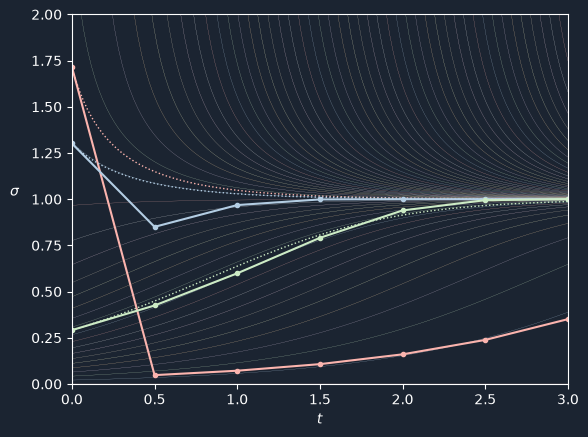

In [9]:
soln = itg.solve_ivp(
    polar_factor_flow_fun,
    (0.0, t_bound),
    np.ravel(X0),
    method=NaiveRK11,
    num_steps=6
)

fig: plt.Figure
ax: plt.Axes
fig, ax = plt.subplots()

ax.set_xlim(0.0, t_bound)
ax.set_ylim(0.0, y_bound)
ax.set_xlabel('$t$')
ax.set_ylabel('$\\sigma$', labelpad=12, rotation=0)

ts = np.linspace(0.0, t_bound, 129)
plot_flow_lines(ax, ts, 1.0, 65)
plot_polygon_of_soln_svs(ax, soln, U, V)

plt.show()

# Error vs step size 3D lol

In [10]:
def plot_3d_error_analysis(ax: plt.Axes3D,
                           method,
                           solver_kwargs_list,
                           error_lower_bound,
                           cmap):
    exact_Xf = polar_factor_flow_exact_helped(t_bound, sv0s, U, V)

    num_times = len(solver_kwargs_list)
    avg_step_sizes = np.empty(num_times)
    global_errors = np.empty(num_times)
    avg_local_errors = np.empty(num_times)
    colors = []
    for i, solver_kwargs in enumerate(solver_kwargs_list):
        color = cmap(1.0 - i / ((num_times - 1) or 1))

        soln = itg.solve_ivp(
            polar_factor_flow_fun,
            (0.0, t_bound),
            np.ravel(X0),
            method=method,
            **solver_kwargs,
        )

        approx_X = soln.y.T.reshape((*soln.t.shape, out_dim, in_dim))

        global_error = np.linalg.matrix_norm(approx_X[-1] - exact_Xf)

        step_sizes = soln.t[1:] - soln.t[:-1]
        error_ts = soln.t[:-1]
        local_error_curve = np.empty_like(step_sizes)

        for k, h in enumerate(step_sizes):
            approx_extended = polar_factor_flow_exact_helped(h, np.diagonal(U.T @ approx_X[k] @ V), U, V)
            local_error_curve[k] = np.linalg.matrix_norm(approx_X[k+1] - approx_extended)

        ax.plot(
            error_ts,
            step_sizes,
            local_error_curve,
            '.-',
            markersize=np.exp2(-0.5 * i),
            linewidth=0.5,
            color=color,
            label='$\\left\\Vert E_L \\right\\Vert$' if i == 0 else None,
        )

        ax.fill_between(
            error_ts, step_sizes, np.full_like(step_sizes, error_lower_bound),
            error_ts, step_sizes, local_error_curve,
            color=color, linewidth=0.0, alpha=0.125,
        )

        avg_step_sizes[i] = t_bound / len(step_sizes)
        global_errors[i] = global_error
        avg_local_errors[i] = np.average(local_error_curve, weights=step_sizes)
        colors.append(color)

    ax.scatter3D(0.0, avg_step_sizes, avg_local_errors, marker=mpl.markers.MarkerStyle('o', fillstyle='none'), c=np.clip(colors, 0.0, 1.0), label='$\\overline{\\left\\Vert E_L \\right\\Vert}$')
    ax.scatter3D(0.0, avg_step_sizes, global_errors, marker='x', c=np.clip(colors, 0.0, 1.0), label='$\\left\\Vert E_G \\right\\Vert$')

Do it for naive Euler.

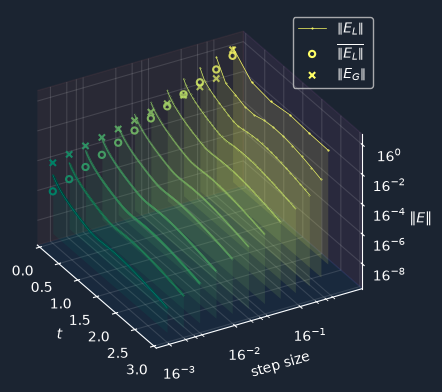

In [11]:
fig: plt.Figure = plt.figure()
ax: plt.Axes3D = fig.add_subplot(projection='3d')
ax.set_proj_type('ortho')
# ax.view_init(elev=0, azim=0, roll=0)
# ax.view_init(elev=0, azim=-90, roll=0)
# ax.view_init(elev=90, azim=0, roll=90)
ax.view_init(elev=30, azim=-30, roll=0)

ax.set_xlabel('$t$')
ax.set_xmargin(0)

ax.set_ylabel('step size')
ax.set_yscale('log', **log_scale_kwargs)

ax.set_zlabel('$\\Vert E \\Vert$')
ax.set_zmargin(0)
ax.zaxis.set_rotate_label(False)
ax.set_zscale('log', **log_scale_kwargs)

cmap = mpl.colormaps['summer']

solver_kwargs_list = [dict(num_steps = (1 << i) * 6) for i in range(12)]
error_lower_bound = np.exp2(-36)
plot_3d_error_analysis(ax, NaiveRK11, solver_kwargs_list, error_lower_bound, cmap)

ax.legend()

plt.show()

# Again, for Adaptive Step Sizes

/home/hua/code/Team17/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/ivp.py:626: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)
/tmp/ipykernel_4217/263605267.py:10: RuntimeWarning: invalid value encountered in sqrt
  np.reciprocal(np.sqrt(determinant)),


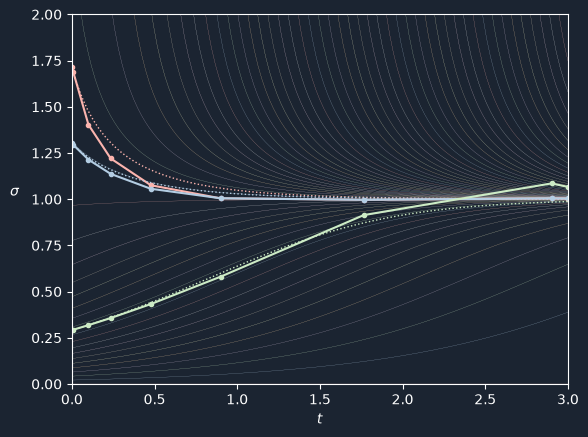

In [12]:
soln = itg.solve_ivp(
    polar_factor_flow_fun,
    (0.0, t_bound),
    np.ravel(X0),
    method=RK11,
    rtol=0.0, atol=np.exp2(-4),
)


fig: plt.Figure
ax: plt.Axes
fig, ax = plt.subplots()

ax.set_xlim(0.0, t_bound)
ax.set_ylim(0.0, y_bound)
ax.set_xlabel('$t$')
ax.set_ylabel('$\\sigma$', labelpad=12, rotation=0)

ts = np.linspace(0.0, t_bound, 129)
plot_flow_lines(ax, ts, 1.0, 65)
plot_polygon_of_soln_svs(ax, soln, U, V)

plt.show()

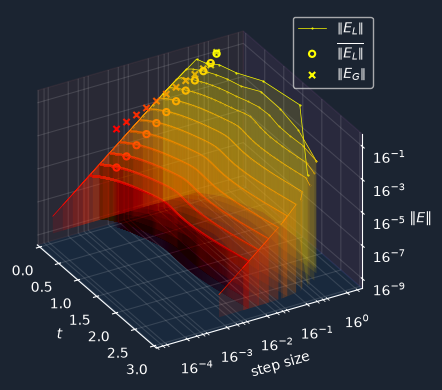

In [13]:
fig: plt.Figure = plt.figure()
ax: plt.Axes3D = fig.add_subplot(projection='3d')
ax.set_proj_type('ortho')
# ax.view_init(elev=0, azim=0, roll=0)
# ax.view_init(elev=0, azim=-90, roll=0)
# ax.view_init(elev=90, azim=0, roll=90)
ax.view_init(elev=30, azim=-30, roll=0)

ax.set_xlabel('$t$')
ax.set_xmargin(0)

ax.set_ylabel('step size')
ax.set_yscale('log', **log_scale_kwargs)

ax.set_zlabel('$\\Vert E \\Vert$')
ax.set_zmargin(0)
ax.zaxis.set_rotate_label(False)
ax.set_zscale('log', **log_scale_kwargs)

cmap = mpl.colormaps['autumn']

solver_kwargs_list = [dict(rtol=0.0, atol=np.exp2(-2*i-4)) for i in range(12)]
plot_3d_error_analysis(ax, RK11, solver_kwargs_list, error_lower_bound, cmap)

ax.legend()

plt.show()